In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
!pip install opencv-python

In [3]:
PROJECT_ROOT = Path("..")
IMAGES_DIR = PROJECT_ROOT / "images"

CONCHA_DIR = IMAGES_DIR / "concha"
PEDRA_DIR = IMAGES_DIR / "pedra"

conchas = sorted(CONCHA_DIR.glob("*.jpg"))
pedras = sorted(PEDRA_DIR.glob("*.jpg"))

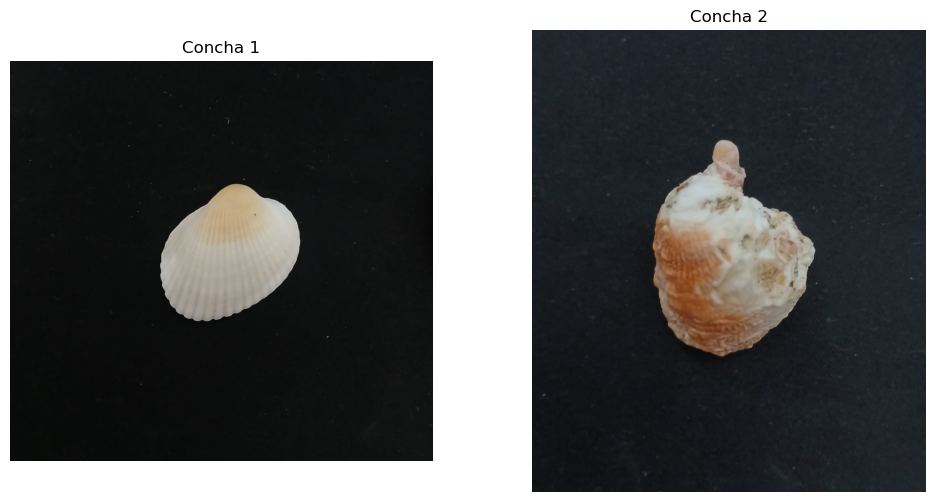

In [4]:
image_1 = cv2.imread(str(conchas[0]))
image_2 = cv2.imread(str(conchas[1]))

fig, axes = plt.subplots(1,2, figsize=(12,6))

axes[0].imshow(cv2.cvtColor(image_1, cv2.COLOR_BGR2RGB))
axes[0].set_title("Concha 1")

axes[1].imshow(cv2.cvtColor(image_2, cv2.COLOR_BGR2RGB))
axes[1].set_title("Concha 2")

for ax in axes:
    ax.axis("off")

plt.show()

In [5]:
orb = cv2.ORB_create()

In [6]:
kp1, des1 = orb.detectAndCompute(image_1, None)
kp2, des2 = orb.detectAndCompute(image_2, None)

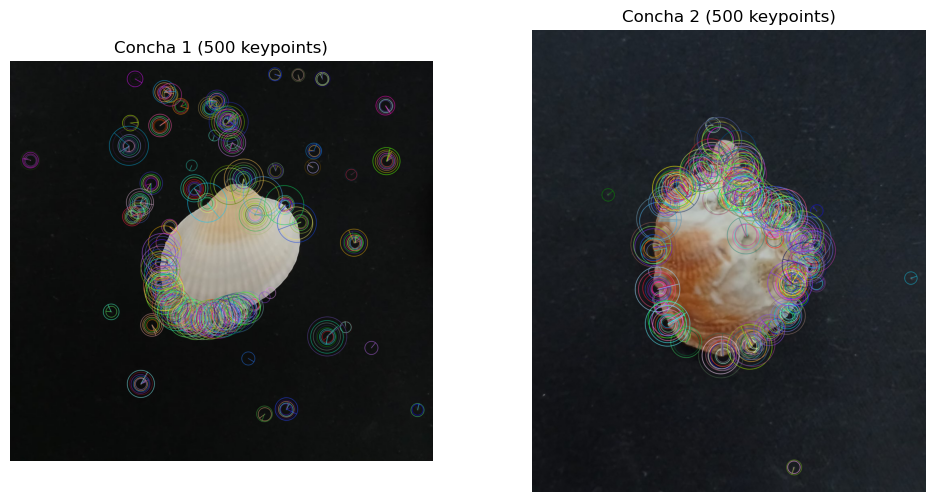

In [7]:
image_1_kp = cv2.drawKeypoints(
    image_1,
    kp1,
    None,
    flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
)

image_2_kp = cv2.drawKeypoints(
    image_2,
    kp2,
    None,
    flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
)

fig, axes = plt.subplots(1,2, figsize=(12,6))

axes[0].imshow(cv2.cvtColor(image_1_kp, cv2.COLOR_BGR2RGB))
axes[0].set_title(f"Concha 1 ({len(kp1)} keypoints)")

axes[1].imshow(cv2.cvtColor(image_2_kp, cv2.COLOR_BGR2RGB))
axes[1].set_title(f"Concha 2 ({len(kp2)} keypoints)")

for ax in axes:
    ax.axis("off")

plt.show()

In [8]:
bf = cv2.BFMatcher(
    cv2.NORM_HAMMING,
    crossCheck=True
)

matches = bf.match(des1, des2)

matches = sorted(
    matches,
    key=lambda x: x.distance
)

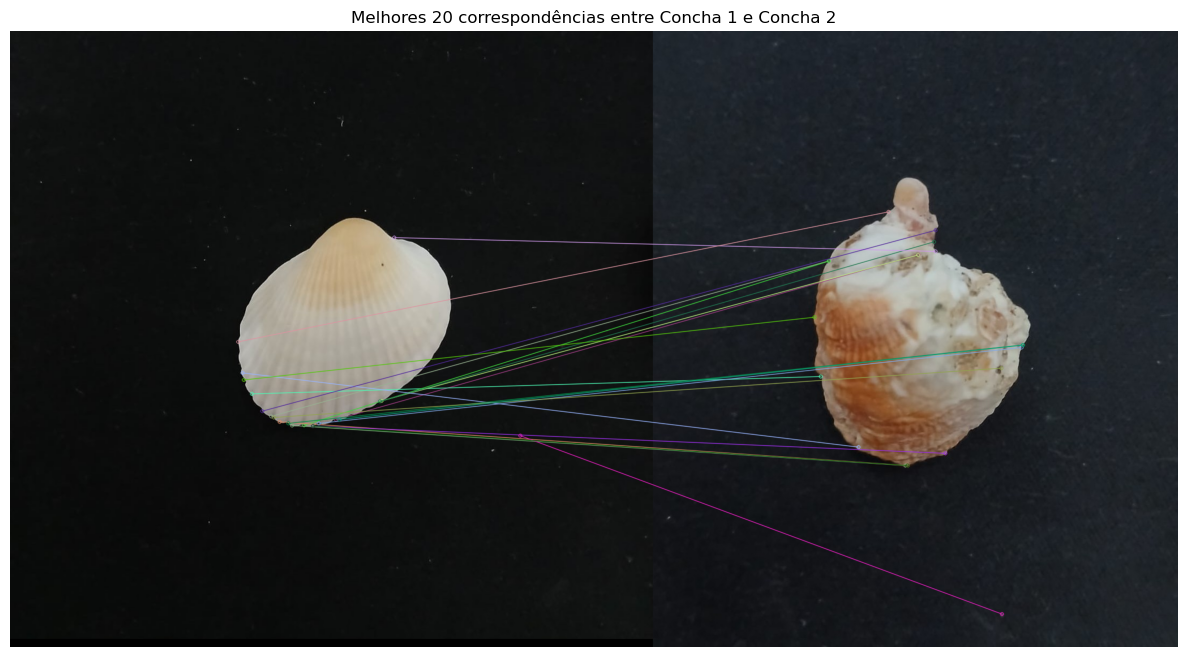

In [9]:
num = 20

image_matches = cv2.drawMatches(
    cv2.cvtColor(image_1, cv2.COLOR_BGR2RGB),
    kp1,
    cv2.cvtColor(image_2, cv2.COLOR_BGR2RGB),
    kp2,
    matches[:num],
    None,
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
)

plt.figure(figsize=(16,8))
plt.imshow(image_matches)
plt.title(f"Melhores {num} correspondências entre Concha 1 e Concha 2")
plt.axis("off")
plt.show()

In [10]:
print("========== RESULTADOS ==========")
print(f"Keypoints Concha 1: {len(kp1)}")
print(f"Keypoints Concha 2: {len(kp2)}")
print(f"Matches encontrados: {len(matches)}")

========== RESULTADOS ==========
Keypoints Concha 1: 500
Keypoints Concha 2: 500
Matches encontrados: 96
